In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from community import community_louvain
from networkx.algorithms import bipartite
from networkx.drawing.layout import bipartite_layout
from matplotlib.patches import Polygon
from scipy.spatial import ConvexHull
import numpy as np
import matplotlib.patches as mpatches
from collections import Counter

In [2]:
# load genes
RNAAgeCalcP = 'C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/00geneRNAAgeCalc-08202025.csv'
EpigeneticsP = 'C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/01EpigeneticCLocks_CpG_GeneAnnotations-08202025.csv'
NewTrainningP = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/06tranningclock-08152025/00elasticnet-08152025/02elastic_net_nonzero_coefficients-08152025.csv"
GSEP = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/gse_columns.csv"
UTHealthP = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/uthealth_columns.csv"
VABBP = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/vabb_columns.csv"
ensembl2symbolP = "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/00databases/03references/03epiclocks/ensembl_to_gene.csv"
# Load the CSV files
RNAAgeCalc = pd.read_csv(RNAAgeCalcP)
Epigenetics = pd.read_csv(EpigeneticsP)
NewTraining = pd.read_csv(NewTrainningP)
GSE = pd.read_csv(GSEP)
UTHealth = pd.read_csv(UTHealthP)
VABB = pd.read_csv(VABBP)
symbol_to_ensembl = pd.read_csv(ensembl2symbolP)  # Replace with your file path

In [3]:
# -------------------------
# Mapping KPANN symbols to Ensembl
# -------------------------
# Create a mapping dictionary
symbol_dict = dict(zip(symbol_to_ensembl['gene'], symbol_to_ensembl['ensemblID']))

# Example datasets
datasets = {
    'GSE': 'Genes',
    'UTHealth': 'Genes',
    'VABB': 'Genes'
}
# Add Ensembl Gene ID to each dataset
for ds_name, gene_col in datasets.items():
    df = globals()[ds_name]  # Get DataFrame by name
    # Ensure column exists
    if gene_col in df.columns:
        df['EnsemblID'] = df[gene_col].map(lambda x: symbol_dict.get(x) if pd.notna(x) else None)

# Extract unique gene symbols
GSE_genes = set(GSE['EnsemblID'].dropna())
UTHealth_genes = set(UTHealth['EnsemblID'].dropna())
VABB_genes = set(VABB['EnsemblID'].dropna())
# Find the intersection of all three sets
common_genes = GSE_genes & UTHealth_genes & VABB_genes

# Plot Venn diagram
#plt.figure(figsize=(8, 8))
#venn3([GSE_genes, UTHealth_genes, VABB_genes],
#      set_labels=('GSE', 'UTHealth', 'VABB'))

#plt.title("Venn Diagram of Gene Symbols")
#plt.show()

# common_genes is a set of Ensembl IDs
df_common = pd.DataFrame({
    'Ensembl': list(common_genes),
    'Clock': 'KPANN',
    'Type': 'Transcriptome'
})

df_common.reset_index(drop=True, inplace=True)
df_common.head()

,Ensembl,Clock,Type
0,ENSG00000083123,KPANN,Transcriptome
1,ENSG00000162813,KPANN,Transcriptome
2,ENSG00000136143,KPANN,Transcriptome
3,ENSG00000106624,KPANN,Transcriptome
4,ENSG00000141736,KPANN,Transcriptome


In [4]:
# -------------------------
# Filter only brain tissues in RNASeq signatures
# -------------------------
# Create new DataFrame
df_brain_nodes = pd.DataFrame({
    'Ensembl': RNAAgeCalc['Ensembl'],
    'Clock': RNAAgeCalc['Signature'],
    'Type': 'Transcriptome'
})
# Original list of clocks
unique_clocks = ['DESeq2', 'Pearson', 'Dev', 'deMagalhaes', 'GenAge', 'GTExAge', 'Peters', 'all']
# Update names: replace 'all' with 'All' and prepend 'RNAAgeCalc:' to all
updated_clocks = [f"RNAAgeCalc:{c.capitalize()}" if c.lower() == 'all' else f"RNAAgeCalc:{c}" for c in unique_clocks]
df_brain_nodes.reset_index(drop=True, inplace=True)
# Create mapping from old Clock names to updated Clock names
clock_map = dict(zip(unique_clocks, updated_clocks))
# Update Clock column in the DataFrame
df_brain_nodes['Clock'] = df_brain_nodes['Clock'].map(clock_map)
df_brain_nodes.head()

,Ensembl,Clock,Type
0,ENSG00000112319,RNAAgeCalc:DESeq2,Transcriptome
1,ENSG00000186081,RNAAgeCalc:DESeq2,Transcriptome
2,ENSG00000147889,RNAAgeCalc:DESeq2,Transcriptome
3,ENSG00000172667,RNAAgeCalc:DESeq2,Transcriptome
4,ENSG00000163564,RNAAgeCalc:DESeq2,Transcriptome


In [5]:
# Assume your DataFrame is called NewTraining
NewTraining['Clock'] = 'ThisStudy'
NewTraining['Type'] = 'Transcriptome'
# Optional: reorder columns if you want
NewTraining = NewTraining[['Unnamed: 0', 'coef', 'Clock', 'Type']]
# Drop the 'coef' column
NewTraining = NewTraining.drop(columns=['coef'])
# Rename column
NewTraining = NewTraining.rename(columns={'Unnamed: 0': 'Ensembl'})
NewTraining.head()

,Ensembl,Clock,Type
0,ENSG00000006210,ThisStudy,Transcriptome
1,ENSG00000007516,ThisStudy,Transcriptome
2,ENSG00000008118,ThisStudy,Transcriptome
3,ENSG00000008283,ThisStudy,Transcriptome
4,ENSG00000010818,ThisStudy,Transcriptome


In [6]:
# Assume your DataFrame is called Epigenetics
# Keep only the first Ensembl ID if multiple are separated by ';'
Epigenetics['Ensembl'] = Epigenetics['EnsemblID'].str.split(';').str[0]
# Create the new DataFrame
df_epigenetic_nodes = pd.DataFrame({
    'Ensembl': Epigenetics['Ensembl'],
    'Clock': Epigenetics['Clock'],
    'Type': 'Epigenetic'
})
# Drop rows where Ensembl is missing
df_epigenetic_nodes = df_epigenetic_nodes.dropna(subset=['Ensembl']).reset_index(drop=True)
# Remove epiTOc2 from the clock list
df_epigenetic_nodes = df_epigenetic_nodes[df_epigenetic_nodes["Clock"] != "EpiTOC1"]
# Reset index if needed
df_epigenetic_nodes = df_epigenetic_nodes.reset_index(drop=True)
# Check
df_epigenetic_nodes.head()

,Ensembl,Clock,Type
0,ENSG00000134202,DNAmClockCortical,Epigenetic
1,ENSG00000143156,DNAmClockCortical,Epigenetic
2,ENSG00000174606,DNAmClockCortical,Epigenetic
3,ENSG00000117308,DNAmClockCortical,Epigenetic
4,ENSG00000168118,DNAmClockCortical,Epigenetic


In [7]:
# -------------------------
# Merging objects
# -------------------------
# Concatenate all nodes into a single DataFrame
all_nodes = pd.concat([df_common, df_brain_nodes, NewTraining, df_epigenetic_nodes], axis=0, ignore_index=True)
# Remove rows where 'Ensembl' is NA
all_nodes = all_nodes.dropna(subset=["Ensembl"])
all_nodes = all_nodes[all_nodes["Ensembl"] != "NA"]
# Optional: reset the index
all_nodes = all_nodes.reset_index(drop=True)
# Check
all_nodes.head()

,Ensembl,Clock,Type
0,ENSG00000083123,KPANN,Transcriptome
1,ENSG00000162813,KPANN,Transcriptome
2,ENSG00000136143,KPANN,Transcriptome
3,ENSG00000106624,KPANN,Transcriptome
4,ENSG00000141736,KPANN,Transcriptome


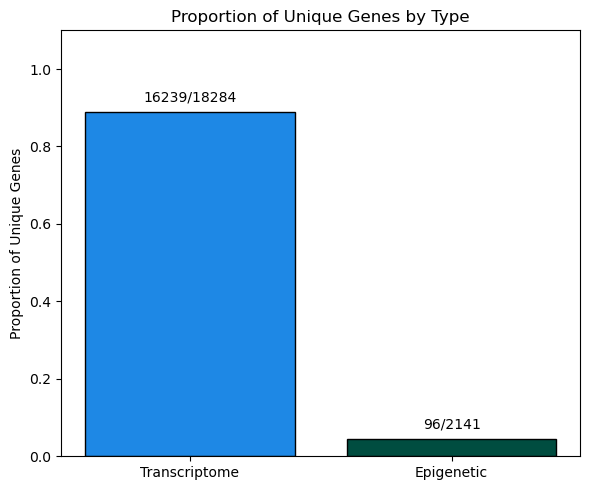

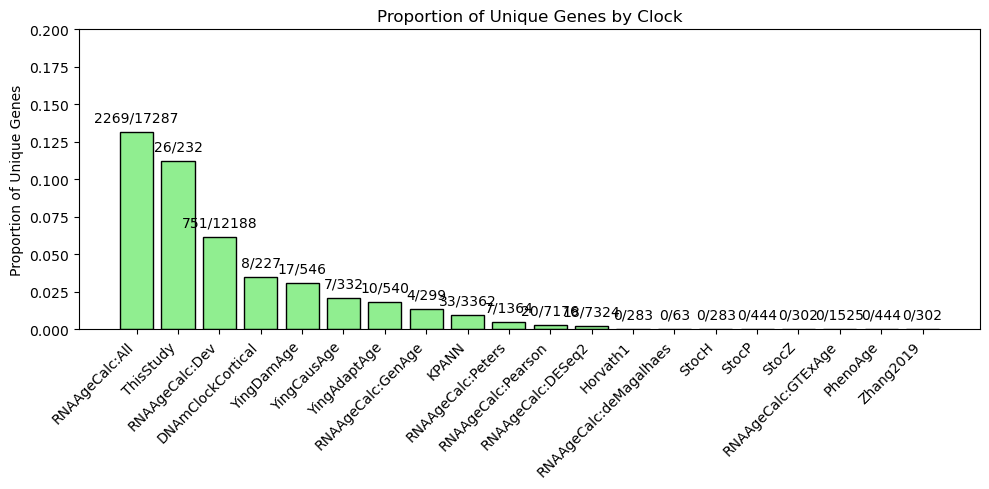

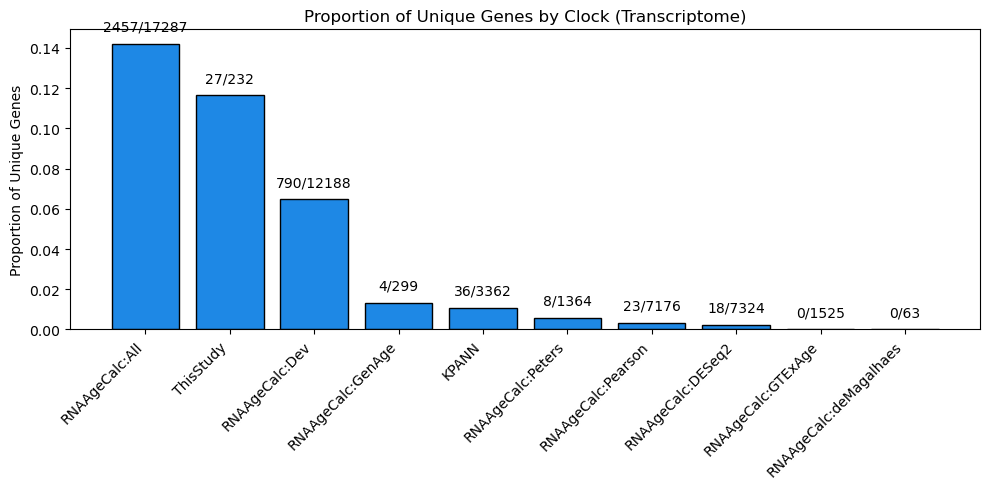

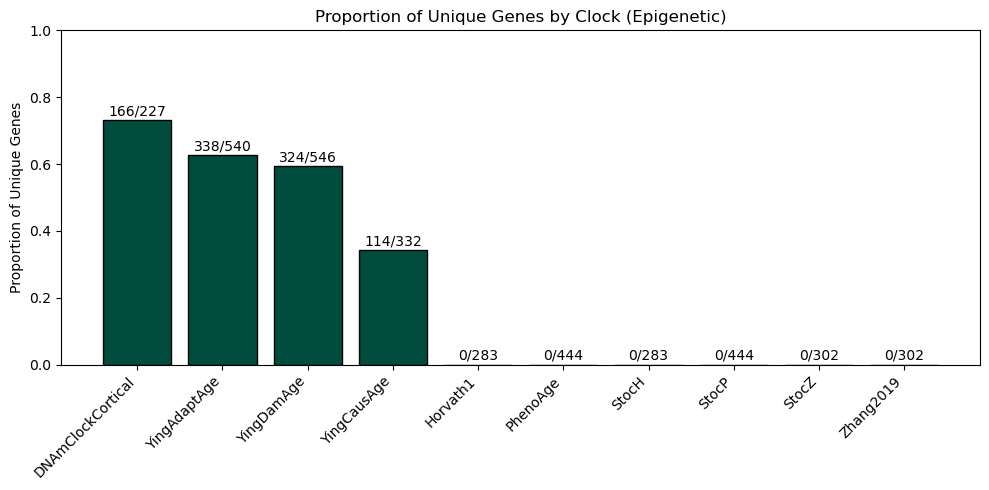

In [8]:
# Work on copy
df = all_nodes.copy()
df = df.drop_duplicates(subset=["Ensembl", "Clock", "Type"])

# -------------------------------
# Proportion of unique genes by Type
# -------------------------------

# total genes per type
total_by_type = df.groupby("Type")["Ensembl"].nunique()

# sets of genes by type
trans_genes = set(df[df["Type"]=="Transcriptome"]["Ensembl"])
epi_genes   = set(df[df["Type"]=="Epigenetic"]["Ensembl"])

# unique sets
unique_trans = trans_genes - epi_genes
unique_epi   = epi_genes - trans_genes

unique_by_type = pd.Series({
    "Transcriptome": len(unique_trans),
    "Epigenetic": len(unique_epi)
})

# proportions dataframe with counts
prop_by_type = pd.DataFrame({
    "Type": unique_by_type.index,
    "UniqueCount": unique_by_type.values,
    "TotalCount": [total_by_type[t] for t in unique_by_type.index],
})
prop_by_type["Proportion"] = prop_by_type["UniqueCount"] / prop_by_type["TotalCount"]

# sort
prop_by_type = prop_by_type.sort_values("Proportion", ascending=False)

# color mapping
type_colors = {"Transcriptome": "#1E88E5", "Epigenetic": "#004D40"}

# plot
plt.figure(figsize=(6,5))
bars = plt.bar(prop_by_type["Type"], prop_by_type["Proportion"], 
               color=[type_colors[t] for t in prop_by_type["Type"]],
               edgecolor="black")

# add labels
for bar, (unique, total) in zip(bars, zip(prop_by_type["UniqueCount"], prop_by_type["TotalCount"])):
    height = bar.get_height()
    label = f"{unique}/{total}"
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, 
             label, ha="center", va="bottom")

plt.ylabel("Proportion of Unique Genes")
plt.title("Proportion of Unique Genes by Type")
plt.ylim(0,1.1)
plt.tight_layout()
# Save the plot to a file
plt.savefig("00Fig7a-08282025.pdf", dpi=600, tight_layout=True)
plt.show()

# -------------------------------
# Proportion of unique genes by Clock
# -------------------------------
prop_by_clock = []
for clock, sub in df.groupby("Clock"):
    genes = set(sub["Ensembl"])
    other_genes = set(df[df["Clock"] != clock]["Ensembl"])
    unique_genes = genes - other_genes
    total = len(genes)
    unique = len(unique_genes)
    prop = unique / total if total > 0 else 0
    prop_by_clock.append([clock, prop, unique, total])

prop_by_clock = pd.DataFrame(prop_by_clock, 
                             columns=["Clock", "Proportion", "UniqueCount", "TotalCount"])

# sort
prop_by_clock = prop_by_clock.sort_values("Proportion", ascending=False)

# plot
plt.figure(figsize=(10,5))
bars = plt.bar(prop_by_clock["Clock"], prop_by_clock["Proportion"], 
               color="lightgreen", edgecolor="black")

# add labels
for bar, (unique, total) in zip(bars, zip(prop_by_clock["UniqueCount"], prop_by_clock["TotalCount"])):
    height = bar.get_height()
    label = f"{unique}/{total}"
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, 
             label, ha="center", va="bottom")

plt.ylabel("Proportion of Unique Genes")
plt.title("Proportion of Unique Genes by Clock")
plt.ylim(0,0.2)   # cap at 0.2
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("00Fig7b-08282025.pdf", dpi=600, tight_layout=True)
plt.show()

# -------------------------------
# Proportion of unique genes by Clock, split by Type
# -------------------------------
for typ in ["Transcriptome", "Epigenetic"]:
    sub_df = df[df["Type"]==typ].copy()
    
    prop_by_clock = []
    for clock, group in sub_df.groupby("Clock"):
        genes = set(group["Ensembl"])
        # other genes of the same type but other clocks
        other_genes = set(sub_df[sub_df["Clock"] != clock]["Ensembl"])
        unique_genes = genes - other_genes
        total = len(genes)
        unique = len(unique_genes)
        prop = unique / total if total > 0 else 0
        prop_by_clock.append([clock, prop, unique, total])
    
    prop_by_clock = pd.DataFrame(prop_by_clock, columns=["Clock", "Proportion", "UniqueCount", "TotalCount"])
    prop_by_clock = prop_by_clock.sort_values("Proportion", ascending=False)
    
    # plot
    plt.figure(figsize=(10,5))
    bars = plt.bar(prop_by_clock["Clock"], prop_by_clock["Proportion"], 
                   color="#1E88E5" if typ=="Transcriptome" else "#004D40", 
                   edgecolor="black")
    
    # annotate with "unique/total"
    for bar, (unique, total) in zip(bars, zip(prop_by_clock["UniqueCount"], prop_by_clock["TotalCount"])):
        height = bar.get_height()
        label = f"{unique}/{total}"
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, label, ha="center", va="bottom")
    
    plt.ylabel("Proportion of Unique Genes")
    plt.title(f"Proportion of Unique Genes by Clock ({typ})")
    
    # set y-limit only for Epigenetic
    if typ=="Epigenetic":
        plt.ylim(0,1.0)
    
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("00Fig7b_{typ}_-08282025.pdf", dpi=600, tight_layout=True)
    plt.show()

In [9]:
# -------------------------
# Save as CSV
# -------------------------
#all_nodes.to_csv("C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/03merged_genes-08212025.csv", index=False)

In [18]:
# -------------------------
# Build bipartite graph (all genes)
# -------------------------
G = nx.Graph()
clock_nodes = set()
gene_nodes = set()

for _, row in all_nodes.iterrows():
    clock = row['Clock']
    gene = row['Ensembl']
    node_type = row['Type']

    # Add nodes
    G.add_node(clock, bipartite="clock", type=node_type)
    G.add_node(gene, bipartite="gene", type="gene")

    clock_nodes.add(clock)
    gene_nodes.add(gene)

    # Add edge
    G.add_edge(clock, gene)

# Convert to lists if needed
clock_nodes = list(clock_nodes)
gene_nodes = list(gene_nodes)

# -------------------------
# Louvain clustering (topology only)
# -------------------------
partition = community_louvain.best_partition(G, random_state=42)
nx.set_node_attributes(G, partition, "cluster")

# Generate colors for clusters
clusters = set(partition.values())
palette = sns.color_palette("tab20", len(clusters))
cluster_colors = {c: palette[i] for i, c in enumerate(clusters)}

Genes with >10 connections: 5
['ENSG00000179761', 'ENSG00000174080', 'ENSG00000080815', 'ENSG00000168056', 'ENSG00000128564']


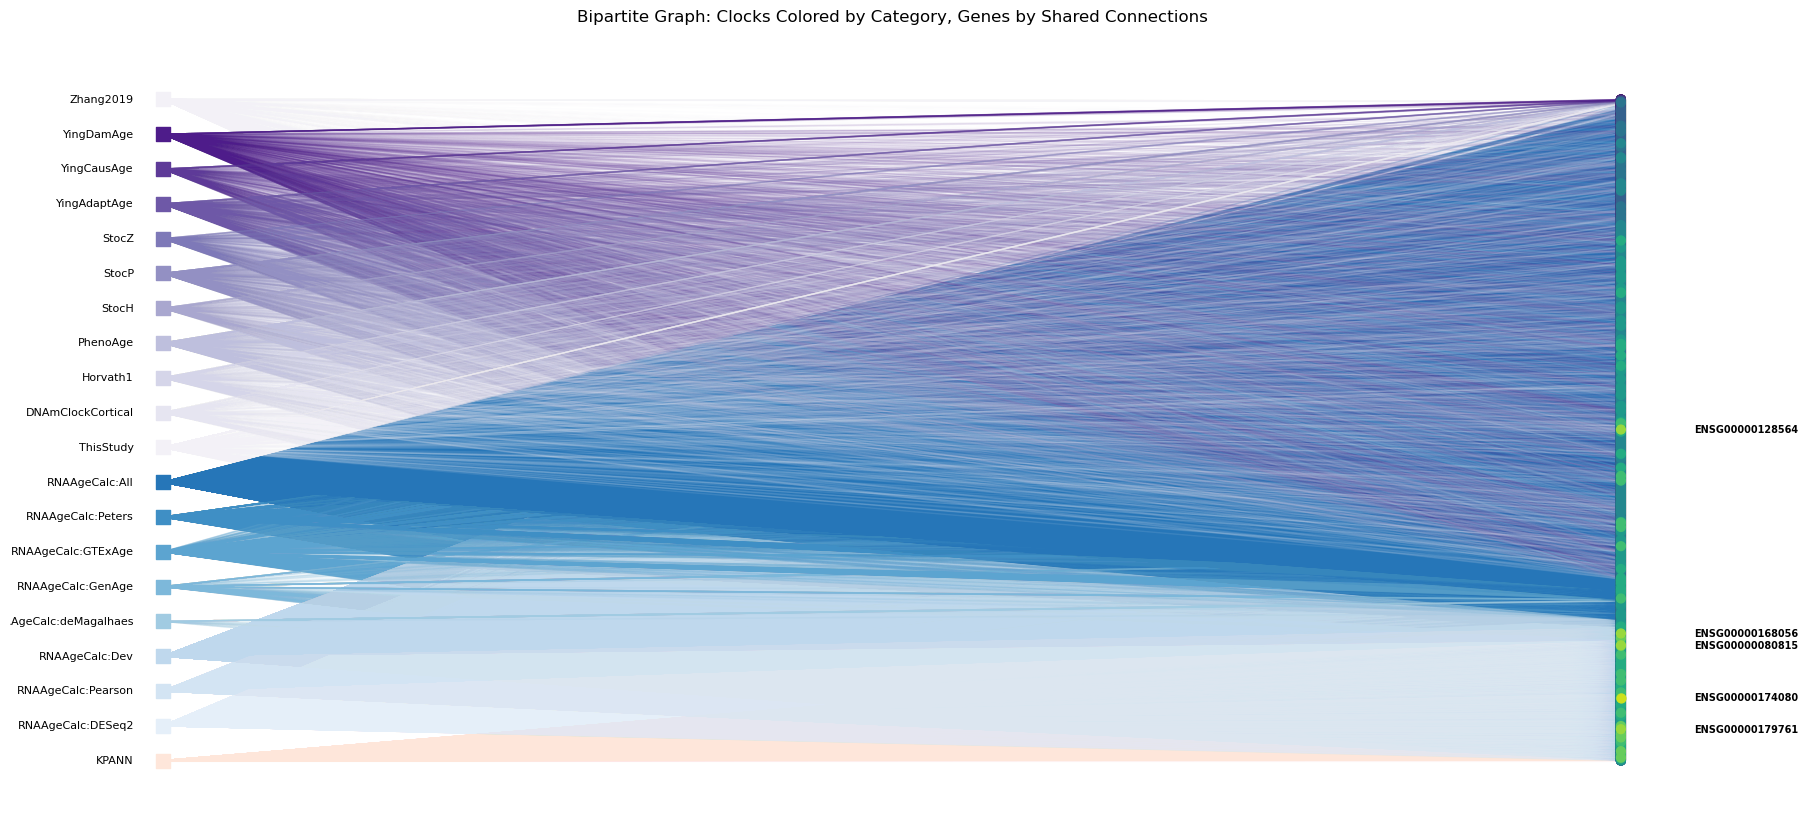

In [20]:
# ----------------------------
# Assume G is already built (no filter on gene connections)
# ----------------------------
clock_nodes = [n for n, d in G.nodes(data=True) if d["bipartite"]=="clock"]
gene_nodes  = [n for n, d in G.nodes(data=True) if d["bipartite"]=="gene"]

# ----------------------------
# Clock category palettes
# ----------------------------
clock_category = {}
for n, d in G.nodes(data=True):
    if d["bipartite"]=="clock":
        if "RNAAgeCalc" in n:
            clock_category[n] = "RNAAgeCalc"
        elif "Epigenetic" in n:
            clock_category[n] = "Epigenetic"
        elif "KPANN" in n:
            clock_category[n] = "KPANN"
        else:
            clock_category[n] = "ThisStudy"

palette_dict = {
    "RNAAgeCalc": sns.color_palette("Blues", 10),
    "Epigenetic": sns.color_palette("Greens", 10),
    "KPANN": sns.color_palette("Reds", 10),
    "ThisStudy": sns.color_palette("Purples", 10)
}

clock_colors = {}
for cat in set(clock_category.values()):
    clocks_in_cat = [c for c in clock_nodes if clock_category[c]==cat]
    pal = palette_dict[cat]
    for i, c in enumerate(clocks_in_cat):
        clock_colors[c] = pal[i % len(pal)]

# ----------------------------
# Gene colors by number of clocks connected
# ----------------------------
gene_degrees = {g: G.degree(g) for g in gene_nodes}
unique_degrees = sorted(list(set(gene_degrees.values())))
gene_palette = sns.color_palette("viridis", len(unique_degrees))
degree_colors = {deg: gene_palette[i] for i, deg in enumerate(unique_degrees)}

# Genes to label (degree > 10)
genes_to_label = [g for g, deg in gene_degrees.items() if deg > 10]
print(f"Genes with >10 connections: {len(genes_to_label)}")
print(genes_to_label)

# ----------------------------
# Layout
# ----------------------------
pos = nx.bipartite_layout(G, nodes=clock_nodes, align="vertical")

plt.figure(figsize=(18, 10))
plt.subplots_adjust(left=0.01, right=0.99, top=0.9, bottom=0.1)

# Draw edges
edges = G.edges()
edge_colors = []
for u, v in edges:
    clock = u if G.nodes[u]["bipartite"]=="clock" else v
    edge_colors.append(clock_colors[clock])
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=edge_colors, alpha=0.1)

# Draw clock nodes
for c in clock_nodes:
    nx.draw_networkx_nodes(G, pos, nodelist=[c],
                           node_color=[clock_colors[c]],
                           node_size=100, node_shape="s")

# Draw gene nodes colored by degree
for deg in unique_degrees:
    genes_in_deg = [g for g in gene_nodes if gene_degrees[g]==deg]
    nx.draw_networkx_nodes(G, pos, nodelist=genes_in_deg,
                           node_color=[degree_colors[deg]]*len(genes_in_deg),
                           node_size=40, node_shape="o")

# ----------------------------
# Label genes with >10 connections (shifted for visibility)
# ----------------------------
for g in genes_to_label:
    plt.text(pos[g][0]+0.05, pos[g][1], g,
             fontsize=7, verticalalignment="center", fontweight="bold")

# ----------------------------
# Label clock nodes
# ----------------------------
pos_clock_labels = {c: (pos[c][0] - 0.02, pos[c][1]) for c in clock_nodes}
nx.draw_networkx_labels(
    G, pos_clock_labels, labels={c: c for c in clock_nodes},
    font_size=8, font_color="black", horizontalalignment="right"
)

plt.axis("off")
plt.title("Bipartite Graph: Clocks Colored by Category, Genes by Shared Connections")
plt.show()

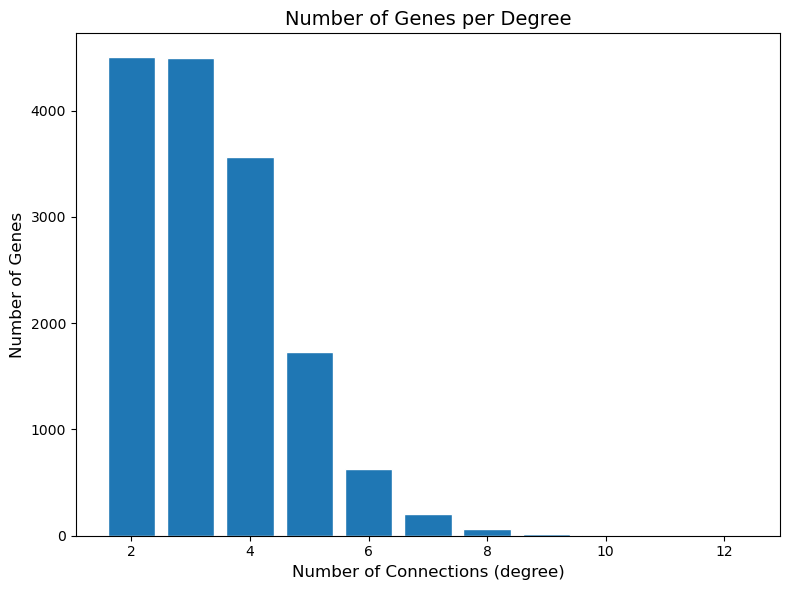

In [13]:
# Extract gene nodes
gene_nodes = [n for n, d in G.nodes(data=True) if d['bipartite'] == 'gene']
# Extract degrees for gene nodes
gene_degree_values = [G.degree(g) for g in gene_nodes]
# Count how many genes have each degree
degree_counts = Counter(gene_degree_values)
# Plot histogram
plt.figure(figsize=(8, 6))
plt.bar(degree_counts.keys(), degree_counts.values(), edgecolor="white")
plt.xlabel("Number of Connections (degree)", fontsize=12)
plt.ylabel("Number of Genes", fontsize=12)
plt.title("Number of Genes per Degree", fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# -------------------------
# Save gene connections
# -------------------------
# Extract gene nodes
gene_nodes = [n for n, d in G.nodes(data=True) if d['bipartite'] == 'gene']

# Compute degrees
gene_degrees = {g: G.degree(g) for g in gene_nodes}

# Save as CSV
df_gene_degrees = pd.DataFrame(list(gene_degrees.items()), columns=["Gene", "NumConnections"])
df_gene_degrees.to_csv(
    "C:/Users/jjm262/OneDrive - Yale University/Documents/Documents/00yale/04fourthyear/01projects/03tclock/02results/08functional/03gene_connections-08212025.csv",
    index=False
)